# ราคารถมือสอง — XGBoost
- ข้อมูล, การรวมชื่อรุ่น และการแบ่ง train/val/test เหมือน notebook MLR ทุกอย่าง
- ตัวแปร: engine_capacity, mileage, car_age + brand, model, car_type, fuel_type, gear_type, color (ให้ XGBoost จัดการตัวแปรกลุ่มเอง)
- ทำนาย `log(ราคา)` แต่วัดผลบนราคาจริง
- ไม่ต้องทดสอบ assumption แบบ MLR เพราะต้นไม้ไม่ได้สมมติว่าความสัมพันธ์เป็นเส้นตรงหรือ residual เป็น normal

> ต้อง mount Google Drive ก่อนรัน

## 0. Import และค่าตั้งต้น
รวมค่าที่ใช้ทั้ง notebook ไว้ที่เดียว จะได้แก้ง่าย

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

DATA_PATH = "/content/drive/MyDrive/Project/cardb/car_dataset_v5.1.csv"
# ใช้รันในเครื่อง: ถ้าไม่เจอ path ของ Drive ให้ใช้ไฟล์ในเครื่องแทน (บน Colab ไม่มีผล)
if not os.path.exists(DATA_PATH):
    DATA_PATH = r"D:\Claude\new_project\data\car_dataset_v5.1.csv"

SEED = 99            # เลขสุ่มคงที่ รันกี่ครั้งก็ได้ผลเหมือนเดิม
MAX_CAR_AGE = 25     # ตัดรถอายุเกิน 25 ปีออก (รถคลาสสิก / รถสะสม)
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

NUM_COLS = ["engine_capacity", "mileage", "car_age"]                              # ตัวแปรตัวเลข
CAT_COLS = ["brand", "model", "car_type", "fuel_type", "gear_type", "color"]      # ตัวแปรกลุ่ม
FEATURES = NUM_COLS + CAT_COLS

# ชื่อรุ่นที่เขียนต่างกันแต่เป็นรุ่นเดียวกัน
MODEL_ALIASES = {"ALTIS": "COROLLAALTIS", "NP300NAVARA": "NAVARA"}

# ผล test ของ MLR (จาก notebook MLR) ไว้เทียบ
MLR_TEST = {"model": "MLR final", "RMSE": 192_232, "MAE": 85_432, "MAPE": 0.1380, "R2": 0.9050}

pd.set_option("display.width", 200, "display.max_columns", 50)

## 1. โหลดและทำความสะอาดข้อมูล
- ตัดรถอายุเกิน 25 ปี (เป็นรถสะสม ราคาไม่ตามกฎปกติ)
- ตัดคอลัมน์ `year` ทิ้ง เพราะ `year = 2026 - car_age` พอดี ข้อมูลซ้ำกัน
- รวมชื่อรุ่นที่สะกดต่างกัน เพื่อไม่ให้รุ่นเดียวกันถูกนับเป็นหลายรุ่น

In [2]:
df = pd.read_csv(DATA_PATH)

rows_before = len(df)
df = df[df["car_age"] <= MAX_CAR_AGE]
print(f"ตัดรถอายุเกิน {MAX_CAR_AGE} ปี: {rows_before - len(df)} แถว")

# year = 2026 - car_age พอดี จึงเป็นข้อมูลซ้ำ ตัดทิ้ง
df = df.drop(columns="year")

# รวมชื่อรุ่นที่เขียนต่างกัน (เช่น "CR-V" กับ "CRV"):
# ทำเป็นตัวพิมพ์ใหญ่ ตัดช่องว่าง/ขีดออก แล้วใช้ชื่อที่พบบ่อยที่สุดในกลุ่มนั้นเป็นชื่อเดียว
model_key = df["model"].str.upper().str.replace(r"[^A-Z0-9]", "", regex=True).replace(MODEL_ALIASES)
most_common_name = df.groupby(model_key)["model"].agg(lambda names: names.value_counts().index[0])
df["model"] = model_key.map(most_common_name)

ตัดรถอายุเกิน 25 ปี: 287 แถว


## 2. แบ่ง train / val / test (70 / 15 / 15)
- `train` ใช้สอนโมเดล, `val` ใช้เลือก hyperparameter, `test` ใช้วัดผลสุดท้ายครั้งเดียว
- สุ่มรถ 1 คันจากทุกรุ่นใส่ train ก่อน เพื่อให้โมเดลเคยเห็นทุกรุ่น

In [3]:
# ขั้น 1: สุ่มรถ 1 คันจากทุก (ยี่ห้อ, รุ่น) ไว้ใน train
forced = df.groupby(["brand", "model"]).sample(n=1, random_state=SEED)
rest = df.drop(forced.index)

# ขั้น 2: แบ่งส่วนที่เหลือ ให้ train รวมแล้วได้ 70% ของทั้งหมด
train_rest, temp = train_test_split(rest, train_size=round(TRAIN_SIZE * len(df)) - len(forced), random_state=SEED)
train = pd.concat([forced, train_rest])

# ขั้น 3: แบ่ง 30% ที่เหลือครึ่งต่อครึ่ง เป็น val กับ test
val, test = train_test_split(temp, test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE), random_state=SEED)

print("train / val / test:", len(train), len(val), len(test))

train / val / test: 20872 4472 4473


## 3. เตรียมตัวแปร (features) และ target
- XGBoost จัดการตัวแปรกลุ่มได้เอง เพียงบอกว่าคอลัมน์นั้นเป็น category (`pd.Categorical`)
- กลุ่มที่เป็นไปได้สร้างจาก train เท่านั้น ค่าที่ train ไม่เคยเห็นจะกลายเป็นค่าว่าง (NaN)
- **target เป็น `log(ราคา)`**: ราคารถกระจายเบ้ขวา (รถแพงมากดึงค่า) การเรียน log ทำให้โมเดลสนใจความผิดพลาดแบบ "เป็น %" มากกว่า "เป็นบาท" แล้วค่อย `exp` กลับเป็นบาทตอนวัดผล (back-transform)

In [4]:
def make_features(data):
    """เลือกคอลัมน์ที่ใช้ แล้วแปลงตัวแปรกลุ่มเป็น category (ค่าที่ไม่มีใน train จะเป็น NaN)"""
    X = data[FEATURES].copy()
    for col in CAT_COLS:
        levels = sorted(train[col].unique())
        X[col] = pd.Categorical(data[col].where(data[col].isin(levels)), categories=levels)
    return X


X_train = make_features(train)
X_val = make_features(val)
X_test = make_features(test)
y_train_log = np.log(train["price"])   # ให้โมเดลเรียนรู้ log(ราคา)
print(X_train.shape)

(20872, 9)


## 4. ฟังก์ชันวัดผล
ใช้ 4 ตัวชี้วัด (คำนวณบนราคาจริงเป็นบาท):
- **RMSE** = รากของค่าเฉลี่ย error ยกกำลังสอง ลงโทษ error ใหญ่ ๆ หนัก (หน่วยบาท ยิ่งน้อยยิ่งดี)
- **MAE** = ค่าเฉลี่ยของ error แบบไม่สนทิศทาง อ่านง่าย "พลาดเฉลี่ยกี่บาท" (ยิ่งน้อยยิ่งดี)
- **MAPE** = error เฉลี่ยเป็นสัดส่วนของราคาจริง เช่น 0.11 = พลาดเฉลี่ย 11% (ยิ่งน้อยยิ่งดี)
- **R²** = โมเดลอธิบายความผันผวนของราคาได้กี่ส่วน (1 = สมบูรณ์แบบ, 0 = ไม่ดีกว่าทายค่าเฉลี่ย)

In [5]:
def score(actual, predicted):
    """วัดผลบนราคาจริง (บาท)"""
    return {
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "MAE": mean_absolute_error(actual, predicted),
        "MAPE": np.mean(np.abs(predicted / actual - 1)),
        "R2": r2_score(actual, predicted),
    }

## 5. ลองหลาย config แล้ววัดผลบน validation
XGBoost สร้างต้นไม้ทีละต้น แต่ละต้นแก้ error ของต้นก่อนหน้า (boosting) **hyperparameter** คือค่าที่เราตั้งเองก่อนสอนโมเดล เราลองหลายชุด (grid) แล้วดูผลบน val ยังไม่แตะ test ในขั้นนี้
- `max_depth` = ความลึกของแต่ละต้น (6, 8) ยิ่งลึกยิ่งซับซ้อน
- `min_child_weight` = ขนาดขั้นต่ำของกลุ่มในใบ (5, 20) ยิ่งมากยิ่งไม่ overfit
- `reg_lambda` = ตัวถ่วงให้โมเดลไม่ซับซ้อนเกินไป (1, 10)
- ค่าคงที่: learning_rate 0.03, subsample 0.8, colsample_bytree 0.8
- **early stopping**: ให้สร้างต้นไม้ได้สูงสุด 5,000 ต้น แต่หยุดเมื่อผลบน val ไม่ดีขึ้นต่อเนื่อง 200 ต้น

`gap` = val MAE / train MAE (ยิ่งใกล้ 1 ยิ่ง overfit น้อย)

In [6]:
results = []
models = []
for max_depth in [6, 8]:
    for min_child_weight in [5, 20]:
        for reg_lambda in [1, 10]:
            params = {"max_depth": max_depth, "min_child_weight": min_child_weight, "reg_lambda": reg_lambda}
            model = XGBRegressor(n_estimators=5000, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, **params,
                                 enable_categorical=True, tree_method="hist", max_cat_to_onehot=1,
                                 early_stopping_rounds=200, random_state=SEED, n_jobs=-1)
            start = time.time()
            # หมายเหตุ: val ถูกใช้ทั้งหยุดสร้างต้นไม้ (early stopping) และเลือก config
            model.fit(X_train, y_train_log, eval_set=[(X_val, np.log(val["price"]))], verbose=False)
            seconds = round(time.time() - start, 1)

            # โมเดลทายเป็น log(ราคา) จึงต้อง exp กลับเป็นราคาก่อนวัดผล
            row = score(val["price"], np.exp(model.predict(X_val)))
            row["train_MAE"] = mean_absolute_error(train["price"], np.exp(model.predict(X_train)))
            row["gap"] = row["MAE"] / row["train_MAE"]
            row["params"] = str(params)
            row["sec"] = seconds
            results.append(row)
            models.append(model)

tune = pd.DataFrame(results)
tune.sort_values("MAE").round(4)

,RMSE,MAE,MAPE,R2,train_MAE,gap,params,sec
6,198743.3622,67594.7188,0.1062,0.9151,48784.2695,1.3856,"{'max_depth': 8, 'min_child_weight': 20, 'reg_...",5.6
4,197799.6491,67624.5547,0.1059,0.9159,44315.0859,1.5260,"{'max_depth': 8, 'min_child_weight': 5, 'reg_l...",5.2
5,189057.4408,67672.4766,0.1072,0.9232,46240.6016,1.4635,"{'max_depth': 8, 'min_child_weight': 5, 'reg_l...",6.9
7,190740.0580,67789.8516,0.1070,0.9218,50218.8750,1.3499,"{'max_depth': 8, 'min_child_weight': 20, 'reg_...",6.3
0,202874.6094,67879.5859,0.1067,0.9115,47065.8477,1.4422,"{'max_depth': 6, 'min_child_weight': 5, 'reg_l...",6.1
2,203522.1635,68178.9141,0.1070,0.9110,52113.0625,1.3083,"{'max_depth': 6, 'min_child_weight': 20, 'reg_...",5.3
1,193295.6815,68317.6094,0.1072,0.9197,49707.4297,1.3744,"{'max_depth': 6, 'min_child_weight': 5, 'reg_l...",6.8
3,194554.2104,68350.5547,0.1073,0.9186,52908.8359,1.2919,"{'max_depth': 6, 'min_child_weight': 20, 'reg_...",6.8


## 6. เลือก config ที่ดีที่สุด แล้ววัดผลบน test (ครั้งเดียว)
**กฎ `pick`**: เอา config ที่ val MAE ห่างจากตัวที่ดีที่สุดไม่เกิน 2% มาเป็นกลุ่ม แล้วเลือกตัวที่ `gap` ต่ำสุด
(แม่นใกล้เคียงที่สุด และ overfit น้อยที่สุด) เพราะความต่างแค่ 2% มักเป็นแค่ความบังเอิญ แต่ overfit น้อยกว่าคือข้อดีจริง

In [7]:
near_best = tune[tune["MAE"] <= tune["MAE"].min() * 1.02]
best_i = near_best["gap"].idxmin()
best_model = models[best_i]
n_trees = best_model.best_iteration + 1   # จำนวนต้นไม้ที่ early stopping เลือก
tune.loc[best_i, "params"] += f" n_trees={n_trees}"
print("config ที่เลือก:", tune.loc[best_i, "params"])

test_pred = np.exp(best_model.predict(X_test))
this_test = {"model": "XGBoost", **score(test["price"], test_pred),
             "params": tune.loc[best_i, "params"], "train_MAE": tune.loc[best_i, "train_MAE"],
             "val_MAE": tune.loc[best_i, "MAE"], "val_R2": tune.loc[best_i, "R2"]}
pd.DataFrame([this_test, MLR_TEST]).set_index("model").round(4)

config ที่เลือก: {'max_depth': 6, 'min_child_weight': 20, 'reg_lambda': 10} n_trees=1232


,RMSE,MAE,MAPE,R2,params,train_MAE,val_MAE,val_R2
model,,,,,,,,
XGBoost,148325.2297,65449.207,0.1087,0.9434,"{'max_depth': 6, 'min_child_weight': 20, 'reg_...",52908.8359,68350.5547,0.9186
MLR final,192232.0000,85432.000,0.1380,0.9050,NaN,NaN,NaN,NaN


## 7. ราคาจริง vs ราคาที่ทำนาย (test)
จุดยิ่งใกล้เส้นประสีแดง ยิ่งทายแม่น (แกนเป็นสเกล log เพื่อให้เห็นทั้งรถถูกและรถแพง)

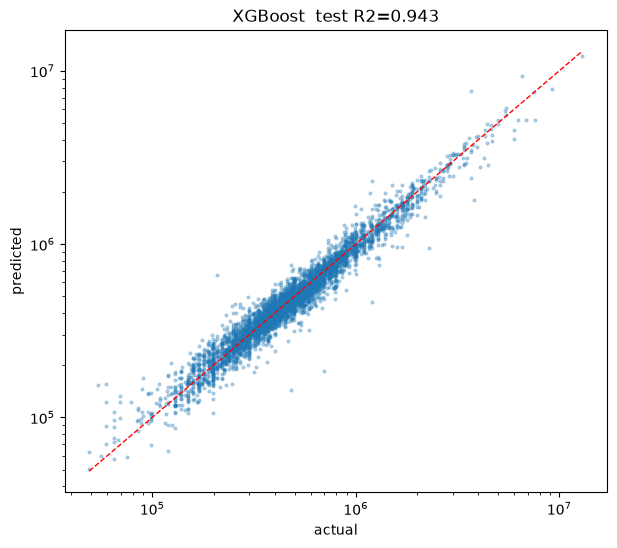

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(test["price"], test_pred, s=4, alpha=0.3)
price_range = [test["price"].min(), test["price"].max()]
ax.plot(price_range, price_range, "r--", lw=1)   # เส้นที่ทายถูกพอดี
ax.set(xscale="log", yscale="log", xlabel="actual", ylabel="predicted",
       title=f"XGBoost  test R2={r2_score(test['price'], test_pred):.3f}")
plt.show()

## 8. ตัวแปรไหนสำคัญ
- `built-in` = ค่าที่โมเดลคำนวณเอง มักให้น้ำหนักเกินกับตัวแปรที่มีหลายค่า (`model` มี ~490 รุ่น)
- `permutation (val)` = สลับค่าของตัวแปรนั้นแบบสุ่มบน val แล้วดูว่าผลแย่ลงแค่ไหน (น่าเชื่อถือกว่า)

In [9]:
perm = permutation_importance(best_model, X_val, np.log(val["price"]), n_repeats=5, random_state=SEED, n_jobs=None)
importance = pd.DataFrame({"built-in": best_model.feature_importances_, "permutation (val)": perm.importances_mean},
                          index=FEATURES)
importance = importance / importance.sum()   # ทำให้แต่ละคอลัมน์รวมกันได้ 1
importance.sort_values("permutation (val)", ascending=False).round(3)

,built-in,permutation (val)
model,0.269,0.545
car_age,0.259,0.382
mileage,0.028,0.024
engine_capacity,0.096,0.017
brand,0.143,0.015
gear_type,0.080,0.009
fuel_type,0.035,0.003
car_type,0.085,0.003
color,0.006,0.002


## 9. ทายพลาดตรงไหน (validation)
แยกตามอายุรถ และ 15 รุ่นที่พลาดมากที่สุด (เฉพาะรุ่นที่มีอย่างน้อย 10 คัน)

In [10]:
errors = val.copy()
errors["pred"] = np.exp(best_model.predict(X_val))
errors["abs_err"] = (errors["pred"] - errors["price"]).abs()   # พลาดกี่บาท
errors["ape"] = errors["abs_err"] / errors["price"]            # พลาดกี่ % ของราคา
errors["age_bin"] = pd.cut(errors["car_age"], [-1, 2, 5, 8, 12, 16, 20, 25])

by_age = errors.groupby("age_bin", observed=True).agg(
    n=("ape", "size"), MAE=("abs_err", "mean"), MAPE=("ape", "mean"))
display(by_age.round(3))

by_model = errors.groupby(["brand", "model"]).agg(
    n=("ape", "size"), MAE=("abs_err", "mean"), MAPE=("ape", "mean"), med_price=("price", "median"))
by_model = by_model[by_model["n"] >= 10]
by_model.sort_values("MAE", ascending=False).head(15).round(3)

,n,MAE,MAPE
age_bin,,,
"(-1, 2]",245,170256.406,0.101
"(2, 5]",1264,82213.047,0.093
"(5, 8]",1352,58853.042,0.097
"(8, 12]",964,54332.786,0.108
"(12, 16]",461,41730.878,0.146
"(16, 20]",126,43743.765,0.173
"(20, 25]",60,55630.120,0.218


n         MAE   MAPE  med_price
brand         model                                     
PORSCHE       CAYENNE   27  345902.873  0.109  2990000.0
MERCEDES-BENZ E220      10  245991.127  0.244  1009500.0
              E300      19  234463.372  0.174  1259000.0
BMW           X5        13  197651.486  0.111  1860000.0
MERCEDES-BENZ C220      15  192821.885  0.154  1150000.0
TOYOTA        ALPHARD   57  175733.040  0.104  1780000.0
MINI          COOPER    16  139163.434  0.139   496500.0
HYUNDAI       STARIA    12  136935.260  0.106  1024500.0
BMW           330E      23  135503.530  0.138   998000.0
              X3        12  133416.047  0.178   604000.0
TOYOTA        VELLFIRE  50  121021.958  0.099  1344000.0
BMW           320D      11  117934.068  0.112   619000.0
MERCEDES-BENZ C350      16  113710.385  0.151   569500.0
              C300      14  107627.011  0.109   879000.0
FORD          EVEREST   71  106575.558  0.125   743000.0